In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from catboost import CatBoostClassifier
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.proportion import proportions_ztest

import matplotlib.style as style
style.use('ggplot')
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [28]:
# Set random seed for reproducibility
np.random.seed(42)

## SECTION 1: DATA LOADING AND BASIC EXPLORATION

This section focuses on loading the dataset and performing initial exploration
to understand the data structure and identify potential issues.

In [29]:
def load_data(file_path):
    """
    Load the credit card default dataset and perform initial cleanup.
    
    Parameters:
    -----------
    file_path : str
        Path to the dataset CSV file
    
    Returns:
    --------
    pandas.DataFrame
        Cleaned dataframe with proper column names
    """
    print("Loading dataset from:", file_path)
    try:
        df = pd.read_csv(file_path)
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        print("Trying with different encoding...")
        try:
            df = pd.read_csv(file_path, encoding='latin1')
        except Exception as e2:
            print(f"Still failed with error: {e2}")
            return None
    
    print("File loaded successfully.")
    print("Original column names:", df.columns.tolist())
    
    # Case 1: Check if the file has X1, X2, etc. columns
    if 'X1' in df.columns:
        print("Detected X1, X2, etc. column format. Renaming columns...")
        column_names = ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 
                        'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
                        'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
                        'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
                        'default']
        
        # Check if column count matches
        if len(df.columns) == len(column_names):
            df.columns = column_names
        else:
            print(f"Warning: Column count mismatch. Expected {len(column_names)}, got {len(df.columns)}")
            # Try to find the target column anyway
            if 'Y' in df.columns:
                df.rename(columns={'Y': 'default'}, inplace=True)
                print("Renamed 'Y' column to 'default'")
    
    # Case 2: Check if the file already has the expected column names
    elif 'default payment next month' in df.columns:
        print("Found 'default payment next month' column - renaming to 'default'")
        df.rename(columns={'default payment next month': 'default'}, inplace=True)
    
    # Print final column names for validation
    print("Final column names:", df.columns.tolist())
    
    # Display basic information
    print("\nDataset shape:", df.shape)
    print("\nFirst few rows:")
    print(df.head())
    print("\nColumn descriptions:")
    print(df.info())
    print("\nSummary statistics:")
    print(df.describe())
    
    # Check for missing values
    missing_values = df.isnull().sum()
    print("\nMissing values in each column:")
    print(missing_values)
    
    return df

In [30]:
def explore_target_distribution(df):
    """
    Explore the distribution of the target variable.
    """
    # Check for different possible target column names
    target_col = None
    possible_names = ['default', 'DEFAULT', 'default payment next month', 'Y']
    
    for name in possible_names:
        if name in df.columns:
            target_col = name
            print(f"Found target column with name: '{target_col}'")
            break
    
    if target_col is None:
        print("Warning: Target column not found. Available columns are:")
        print(df.columns.tolist())
        print("Please check your data or specify the correct target column name.")
        return None
    
    plt.figure(figsize=(10, 6))
    default_counts = df[target_col].value_counts()
    default_perc = df[target_col].value_counts(normalize=True) * 100
    
    print("\nTarget variable distribution:")
    for value, count in default_counts.items():
        print(f"Class {value}: {count} samples ({default_perc[value]:.2f}%)")
    
    # Create a pie chart with dynamic labels based on the actual values
    # Generate labels dynamically based on the index values
    labels = [f'Class {val}' for val in default_counts.index]
    
    # Print debug info
    print(f"Number of classes: {len(default_counts)}")
    print(f"Class values: {default_counts.index.tolist()}")
    print(f"Using labels: {labels}")
    
    # Create explode tuple of the right length
    explode = tuple(0.1 if i == 1 else 0 for i in range(len(default_counts)))
    
    # Create a color list of the right length
    colors = ['#66b3ff', '#ff9999']
    if len(default_counts) > 2:
        # Add more colors if needed
        additional_colors = ['#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6']
        colors.extend(additional_colors[:len(default_counts)-2])
    
    # Now create the pie chart with the correct dimensions
    plt.pie(default_counts, labels=labels, autopct='%1.1f%%', 
            colors=colors[:len(default_counts)], explode=explode)
    plt.title('Distribution of Target Variable', fontsize=16)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig('target_distribution.png')
    plt.show()
    
    # Store the target column name as a global variable for other functions to use
    global TARGET_COLUMN
    TARGET_COLUMN = target_col
    
    return default_perc

In [31]:
def visualize_features(df):
    """
    Create visualizations for key features and their relationships with the target.
    """
    # Distribution of numerical features
    print("\nVisualizing numerical features...")
    numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
    
    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(numerical_features):
        plt.subplot(2, 2, i+1)
        sns.histplot(data=df, x=feature, hue='default', kde=True, bins=30)
        plt.title(f'Distribution of {feature} by Default Status')
    plt.tight_layout()
    plt.savefig('numerical_features_dist.png')
    plt.show()
    
    # Distribution of categorical features
    print("\nVisualizing categorical features...")
    categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0']
    
    plt.figure(figsize=(15, 10))
    for i, feature in enumerate(categorical_features):
        plt.subplot(2, 2, i+1)
        sns.countplot(data=df, x=feature, hue='default')
        plt.title(f'Distribution of {feature} by Default Status')
    plt.tight_layout()
    plt.savefig('categorical_features_dist.png')
    plt.show()
    
    # Correlation heatmap for payment history and bill amounts
    print("\nAnalyzing correlations...")
    payment_cols = [col for col in df.columns if col.startswith('PAY_')]
    bill_cols = [col for col in df.columns if col.startswith('BILL_')]
    
    # Correlation matrix for all numerical features
    corr_matrix = df.corr()
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmax=.3, center=0,
                square=True, linewidths=.5, annot=False)
    plt.title('Correlation Matrix of Features', fontsize=16)
    plt.savefig('correlation_matrix.png')
    plt.show()

In [32]:
# Load the data
df = load_data('loan_data.csv')

Loading dataset from: loan_data.csv
File loaded successfully.
Original column names: ['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']
Detected X1, X2, etc. column format. Renaming columns...
Final column names: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']

Dataset shape: (30001, 25)

First few rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0  ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4   
1   1      20000    2          2         1   24      2      2     -1     -1   
2   2     120000    2          2         2   26     -1      2      0      0   
3   3      90000    2          

Found target column with name: 'default'

Target variable distribution:
Class 0: 23364 samples (77.88%)
Class 1: 6636 samples (22.12%)
Class default payment next month: 1 samples (0.00%)
Number of classes: 3
Class values: ['0', '1', 'default payment next month']
Using labels: ['Class 0', 'Class 1', 'Class default payment next month']


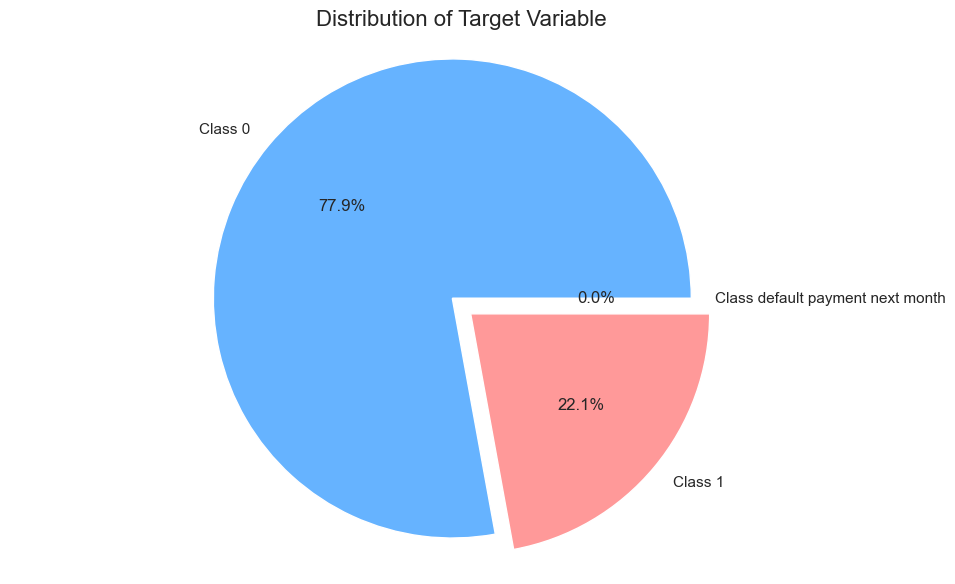

In [33]:
# Explore target distribution
target_distribution = explore_target_distribution(df)

In [34]:
# Visualize features
# visualize_features(df)

## Data Preprocessing and Feature Engineering

In [35]:
def preprocess_data(df):
    """
    Perform data preprocessing and feature engineering.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Raw dataframe with original features
    
    Returns:
    --------
    pandas.DataFrame
        Processed dataframe with new features
    """
    print("\nStarting data preprocessing and feature engineering...")
    
    # Create a copy to avoid modifying the original dataframe
    processed_df = df.copy()
    
    # Handle ID column if it exists
    if 'ID' in processed_df.columns:
        processed_df.drop('ID', axis=1, inplace=True)
    
    # Convert columns to numeric if they aren't already
    for col in processed_df.columns:
        if processed_df[col].dtype == 'object':
            print(f"Converting column '{col}' to numeric")
            processed_df[col] = pd.to_numeric(processed_df[col], errors='coerce')
    
    # Check for non-numeric columns after conversion
    non_numeric_cols = [col for col in processed_df.columns if processed_df[col].dtype == 'object']
    if non_numeric_cols:
        print(f"Warning: The following columns could not be converted to numeric: {non_numeric_cols}")
        print("These columns will be dropped.")
        processed_df = processed_df.drop(columns=non_numeric_cols)
    
    # Print column types after conversion
    print("\nColumn types after conversion:")
    print(processed_df.dtypes)
    
    # Verify essential columns exist
    essential_columns = ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'LIMIT_BAL']
    missing_columns = [col for col in essential_columns if col not in processed_df.columns]
    
    if missing_columns:
        print(f"Warning: The following essential columns are missing: {missing_columns}")
        print("Available columns:", processed_df.columns.tolist())
    
    # Encode categorical variables only if they exist
    # Sex: 1=male, 2=female -> convert to binary 0=male, 1=female
    if 'SEX' in processed_df.columns:
        processed_df['SEX'] = processed_df['SEX'].map({1: 0, 2: 1})
    
    # Education: 1=graduate school, 2=university, 3=high school, 4=others
    # Simplify to: 0=high school or below, 1=university, 2=graduate school
    if 'EDUCATION' in processed_df.columns:
        education_mapping = {1: 2, 2: 1, 3: 0, 4: 0, 5: 0, 6: 0, 0: 0}
        processed_df['EDUCATION'] = processed_df['EDUCATION'].map(education_mapping)
    
    # Marriage: 1=married, 2=single, 3=others -> simplify to binary: 0=not married, 1=married
    if 'MARRIAGE' in processed_df.columns:
        processed_df['MARRIAGE'] = processed_df['MARRIAGE'].map({1: 1, 2: 0, 3: 0, 0: 0})
    
    # Feature Engineering
    print("Creating new features...")
    
    # Get bill and payment columns
    bill_cols = [col for col in processed_df.columns if col.startswith('BILL_')]
    pay_cols = [col for col in processed_df.columns if col.startswith('PAY_AMT')]
    
    # Only create features if we have the necessary columns
    if bill_cols and pay_cols:
        # 1. Total bill amount and payment amount
        processed_df['TOTAL_BILL_AMT'] = processed_df[bill_cols].sum(axis=1)
        processed_df['TOTAL_PAY_AMT'] = processed_df[pay_cols].sum(axis=1)
        
        # 2. Utilization ratio (total bill / credit limit)
        if 'LIMIT_BAL' in processed_df.columns:
            # Ensure values are numeric
            processed_df['LIMIT_BAL'] = pd.to_numeric(processed_df['LIMIT_BAL'], errors='coerce')
            
            # Create utilization ratio where limit is > 0
            mask = processed_df['LIMIT_BAL'] > 0
            processed_df['UTILIZATION_RATIO'] = 0.0  # Default value
            processed_df.loc[mask, 'UTILIZATION_RATIO'] = processed_df.loc[mask, 'TOTAL_BILL_AMT'] / processed_df.loc[mask, 'LIMIT_BAL']
            
            # Handle extreme values
            processed_df['UTILIZATION_RATIO'] = processed_df['UTILIZATION_RATIO'].clip(0, 10)
        
        # 3. Payment ratio (total payment / total bill) where bill > 0
        mask = processed_df['TOTAL_BILL_AMT'] > 0
        processed_df['PAYMENT_RATIO'] = 0.0  # Default value
        processed_df.loc[mask, 'PAYMENT_RATIO'] = processed_df.loc[mask, 'TOTAL_PAY_AMT'] / processed_df.loc[mask, 'TOTAL_BILL_AMT']
        
        # Handle extreme values
        processed_df['PAYMENT_RATIO'] = processed_df['PAYMENT_RATIO'].clip(0, 10)
        
        # 4. Max bill amount
        processed_df['MAX_BILL_AMT'] = processed_df[bill_cols].max(axis=1)
        
        # 5. Min bill amount
        processed_df['MIN_BILL_AMT'] = processed_df[bill_cols].min(axis=1)
        
        # 6. Bill amount standard deviation
        processed_df['BILL_AMT_STD'] = processed_df[bill_cols].std(axis=1)
    else:
        print("Warning: Cannot create bill and payment features - required columns missing")
    
    # Delay features - only if we have the necessary columns
    delay_cols = [col for col in processed_df.columns if col.startswith('PAY_') and not col.startswith('PAY_AMT')]
    
    if delay_cols:
        # 7. Count of delays
        processed_df['DELAY_COUNT'] = (processed_df[delay_cols] > 0).sum(axis=1)
        
        # 8. Max delay
        processed_df['MAX_DELAY'] = processed_df[delay_cols].max(axis=1)
        
        # 9. Weighted delay score
        if len(delay_cols) >= 6:
            # Sort delay columns to ensure correct ordering
            delay_cols_sorted = sorted(delay_cols, 
                                    key=lambda x: int(x.replace('PAY_', '')) if x != 'PAY_0' else 0)
            
            # Apply decreasing weights (most recent month gets highest weight)
            weights = list(range(1, len(delay_cols) + 1))
            weights.reverse()  # Reverse to give higher weight to recent months
            
            processed_df['WEIGHTED_DELAY_SCORE'] = 0
            for feature, weight in zip(delay_cols_sorted, weights):
                # Only positive values indicate delay (clip negative values to 0)
                delay_value = processed_df[feature].clip(lower=0)
                processed_df['WEIGHTED_DELAY_SCORE'] += delay_value * weight
    else:
        print("Warning: Cannot create delay features - required columns missing")
    
    # 10. Age groups - only if AGE column exists
    if 'AGE' in processed_df.columns:
        processed_df['AGE_GROUP'] = pd.cut(processed_df['AGE'], 
                                      bins=[0, 25, 35, 45, 55, 100], 
                                      labels=[0, 1, 2, 3, 4])
        processed_df['AGE_GROUP'] = processed_df['AGE_GROUP'].astype('float').astype('Int64')
    
    # Handle NaN values
    print("\nHandling missing values...")
    for col in processed_df.columns:
        if processed_df[col].isna().sum() > 0:
            print(f"Column '{col}' has {processed_df[col].isna().sum()} missing values.")
            # Fill numeric columns with median
            if pd.api.types.is_numeric_dtype(processed_df[col]):
                median_val = processed_df[col].median()
                processed_df[col] = processed_df[col].fillna(median_val)
                print(f"  - Filled with median: {median_val}")
    
    # Print information about the preprocessed data
    print("\nProcessed data shape:", processed_df.shape)
    
    # List the new features that were created
    new_features = [col for col in processed_df.columns if col not in df.columns]
    print(f"\nNew features created ({len(new_features)}):")
    for feature in new_features:
        print(f" - {feature}")
        if feature in processed_df.columns:  # Make sure the column still exists
            desc = processed_df[feature].describe().to_dict()
            # Print just a few key stats
            print(f"   Stats: mean={desc.get('mean', 'N/A'):.2f}, min={desc.get('min', 'N/A'):.2f}, max={desc.get('max', 'N/A'):.2f}")
    
    return processed_df

In [36]:
def handle_imbalance(X, y, method='smote'):
    """
    Handle class imbalance using different methods.
    
    Parameters:
    -----------
    X : pandas.DataFrame
        Feature matrix
    y : pandas.Series
        Target vector
    method : str
        Method to handle imbalance: 'smote', 'undersampling', 'oversampling', or 'none'
    
    Returns:
    --------
    X_resampled, y_resampled : pandas.DataFrame, pandas.Series
        Resampled feature matrix and target vector
    """
    from collections import Counter
    print(f"\nHandling class imbalance using {method.upper()}...")
    print("Original class distribution:", Counter(y))
    
    if method.lower() == 'none':
        return X, y
    
    # Convert all float columns to float32 to avoid precision issues
    float_cols = X.select_dtypes(include=['float']).columns
    X = X.copy()
    for col in float_cols:
        X[col] = X[col].astype('float32')
    
    # Fix integer columns that might have NaN (which converts them to float)
    int_cols = []
    for col in X.columns:
        if X[col].dtype.name.startswith(('int', 'Int')) or 'GROUP' in col:
            int_cols.append(col)
            # Fill NaNs with mode
            if X[col].isna().any():
                mode_val = X[col].mode()[0]
                X[col] = X[col].fillna(mode_val)
            # Ensure integer type without losing data
            try:
                X[col] = X[col].astype('int32')
            except:
                print(f"Warning: Could not convert column {col} to integer. Using it as float.")
                # If conversion fails, ensure it's a regular float
                X[col] = X[col].astype('float32')
    
    print("Data types after preprocessing:")
    print(X.dtypes.value_counts())
    
    try:
        if method.lower() == 'smote':
            from imblearn.over_sampling import SMOTE
            smote = SMOTE(random_state=42)
            X_resampled, y_resampled = smote.fit_resample(X, y)
        
        elif method.lower() == 'undersampling':
            from imblearn.under_sampling import RandomUnderSampler
            undersampler = RandomUnderSampler(random_state=42)
            X_resampled, y_resampled = undersampler.fit_resample(X, y)
        
        elif method.lower() == 'oversampling':
            from imblearn.over_sampling import RandomOverSampler
            oversampler = RandomOverSampler(random_state=42)
            X_resampled, y_resampled = oversampler.fit_resample(X, y)
        
        print("New class distribution:", Counter(y_resampled))
        return X_resampled, y_resampled
    
    except Exception as e:
        print(f"Error during resampling: {e}")
        print("Falling back to original data without resampling.")
        return X, y

In [37]:
def prepare_train_test_data(df, target_col='default', test_size=0.2):
    """
    Split the data into training and testing sets.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Processed dataframe
    target_col : str
        Name of the target column
    test_size : float
        Proportion of data to use for testing
        
    Returns:
    --------
    X_train, X_test, y_train, y_test : pandas.DataFrame, pandas.DataFrame, pandas.Series, pandas.Series
        Training and testing data
    """
    print("\nSplitting data into training and testing sets...")
    
    # Separate features and target
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    
    print(f"Training set: {X_train.shape[0]} samples")
    print(f"Testing set: {X_test.shape[0]} samples")
    
    return X_train, X_test, y_train, y_test

In [38]:
processed_df = preprocess_data(df)


Starting data preprocessing and feature engineering...
Converting column 'LIMIT_BAL' to numeric
Converting column 'SEX' to numeric
Converting column 'EDUCATION' to numeric
Converting column 'MARRIAGE' to numeric
Converting column 'AGE' to numeric
Converting column 'PAY_0' to numeric
Converting column 'PAY_2' to numeric
Converting column 'PAY_3' to numeric
Converting column 'PAY_4' to numeric
Converting column 'PAY_5' to numeric
Converting column 'PAY_6' to numeric
Converting column 'BILL_AMT1' to numeric
Converting column 'BILL_AMT2' to numeric
Converting column 'BILL_AMT3' to numeric
Converting column 'BILL_AMT4' to numeric
Converting column 'BILL_AMT5' to numeric
Converting column 'BILL_AMT6' to numeric
Converting column 'PAY_AMT1' to numeric
Converting column 'PAY_AMT2' to numeric
Converting column 'PAY_AMT3' to numeric
Converting column 'PAY_AMT4' to numeric
Converting column 'PAY_AMT5' to numeric
Converting column 'PAY_AMT6' to numeric
Converting column 'default' to numeric

Colu

In [39]:
# Split into train and test sets
X_train, X_test, y_train, y_test = prepare_train_test_data(processed_df)


Splitting data into training and testing sets...
Training set: 24000 samples
Testing set: 6001 samples


In [40]:
# Handle class imbalance with SMOTE
X_train_balanced, y_train_balanced = handle_imbalance(X_train, y_train, method='smote')


Handling class imbalance using SMOTE...
Original class distribution: Counter({0.0: 18691, 1.0: 5309})
Data types after preprocessing:
float32    32
int32       2
Name: count, dtype: int64
New class distribution: Counter({0.0: 18691, 1.0: 18691})


## Model Training and Evaluation

In [51]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name="Model"):
    """
    Evaluate model performance using various metrics.
    
    Parameters:
    -----------
    y_true : array-like
        True target values
    y_pred : array-like
        Predicted target values
    y_pred_proba : array-like
        Predicted probabilities
    model_name : str
        Name of the model for display
    """
    # Classification metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    
    print(f"{model_name} Performance Metrics:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{model_name} Confusion Matrix', fontsize=16)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_confusion_matrix.png')
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} ROC Curve', fontsize=16)
    plt.legend(loc="lower right")
    plt.savefig(f'{model_name.lower().replace(" ", "_")}_roc_curve.png')
    plt.show()
    
    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    }

In [41]:
def train_logistic_regression(X_train, y_train, X_test, y_test):
    """
    Train a logistic regression model with cross-validation.
    """
    print("\nTraining Logistic Regression model...")
    
    # Create a pipeline with preprocessing and model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ])
    
    # Cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    
    print(f"Cross-validation ROC-AUC scores: {cv_scores}")
    print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")
    
    # Train the final model on the whole training set
    pipeline.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Evaluate the model
    print("\nLogistic Regression Model Evaluation:")
    evaluate_model(y_test, y_pred, y_pred_proba, model_name="Logistic Regression")
    
    return pipeline

In [42]:
def train_random_forest(X_train, y_train, X_test, y_test):
    """
    Train a random forest model with cross-validation.
    """
    print("\nTraining Random Forest model...")
    
    # Create a pipeline with preprocessing and model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    
    # Cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    
    print(f"Cross-validation ROC-AUC scores: {cv_scores}")
    print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")
    
    # Train the final model on the whole training set
    pipeline.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Evaluate the model
    print("\nRandom Forest Model Evaluation:")
    evaluate_model(y_test, y_pred, y_pred_proba, model_name="Random Forest")
    
    # Feature importance analysis
    rf_model = pipeline.named_steps['clf']
    feature_importance = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 10 most important features:")
    print(feature_importance.head(10))
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15), palette='viridis')
    plt.title('Random Forest Feature Importance', fontsize=16)
    plt.tight_layout()
    plt.savefig('feature_importance.png')
    plt.show()
    
    return pipeline, feature_importance

In [43]:
def train_xgboost(X_train, y_train, X_test, y_test):
    """
    Train an XGBoost model with cross-validation.
    """
    print("\nTraining XGBoost model...")
    
    # Create a pipeline with preprocessing and model
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=5,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss'
        ))
    ])
    
    # Cross-validation
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    
    print(f"Cross-validation ROC-AUC scores: {cv_scores}")
    print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f}, Std: {cv_scores.std():.4f}")
    
    # Train the final model on the whole training set
    pipeline.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    # Evaluate the model
    print("\nXGBoost Model Evaluation:")
    evaluate_model(y_test, y_pred, y_pred_proba, model_name="XGBoost")
    
    return pipeline

### Logistic Regression


Training Logistic Regression model...
Cross-validation ROC-AUC scores: [0.84166746 0.84552253 0.85232901 0.83895377 0.84466287]
Mean CV ROC-AUC: 0.8446, Std: 0.0045

Logistic Regression Model Evaluation:
Logistic Regression Performance Metrics:
Accuracy: 0.7675
Precision: 0.4757
Recall: 0.5026
F1 Score: 0.4888
ROC AUC: 0.7172


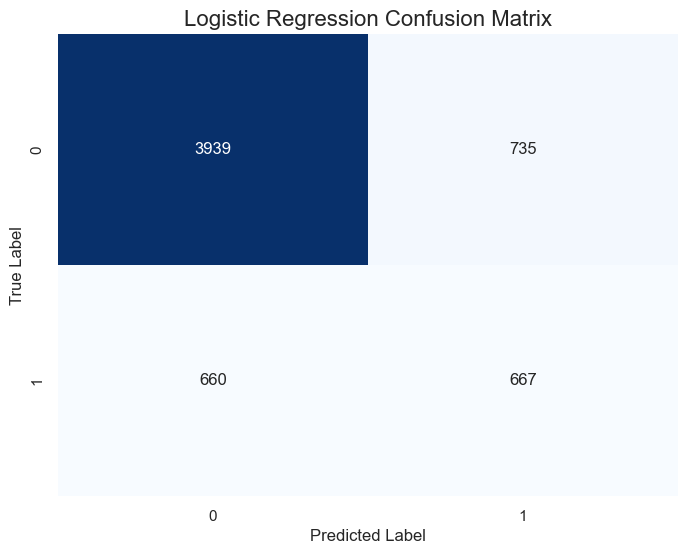

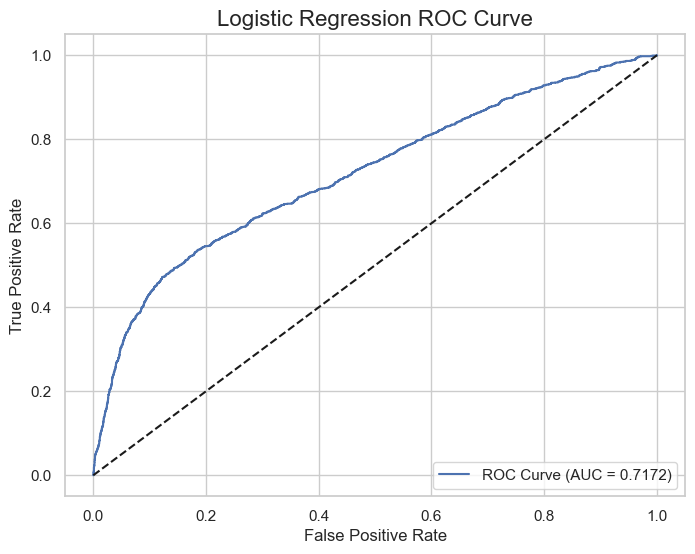


Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.84      0.85      4674
         1.0       0.48      0.50      0.49      1327

    accuracy                           0.77      6001
   macro avg       0.67      0.67      0.67      6001
weighted avg       0.77      0.77      0.77      6001



In [46]:
logreg_model = train_logistic_regression(X_train_balanced, y_train_balanced, X_test, y_test)
y_pred_logreg = logreg_model.predict(X_test)
y_pred_proba_logreg = logreg_model.predict_proba(X_test)[:, 1]

### Random Forest


Training Random Forest model...
Cross-validation ROC-AUC scores: [0.9409244  0.94633645 0.94632895 0.94204575 0.93979123]
Mean CV ROC-AUC: 0.9431, Std: 0.0027

Random Forest Model Evaluation:
Random Forest Performance Metrics:
Accuracy: 0.8097
Precision: 0.6027
Recall: 0.4092
F1 Score: 0.4874
ROC AUC: 0.7603


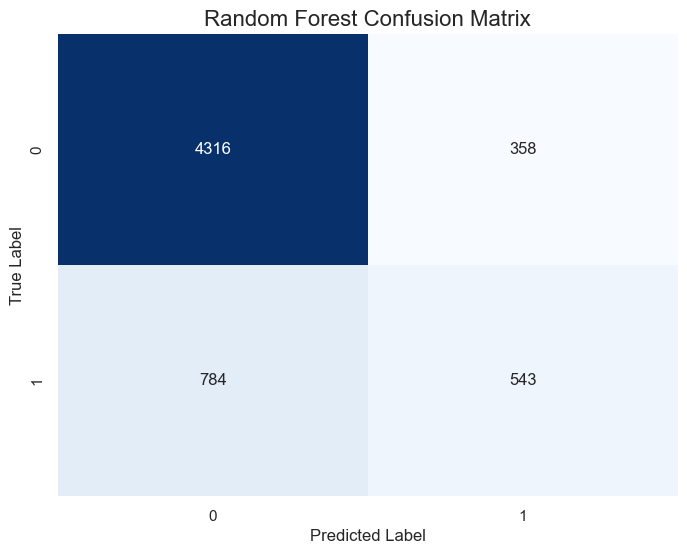

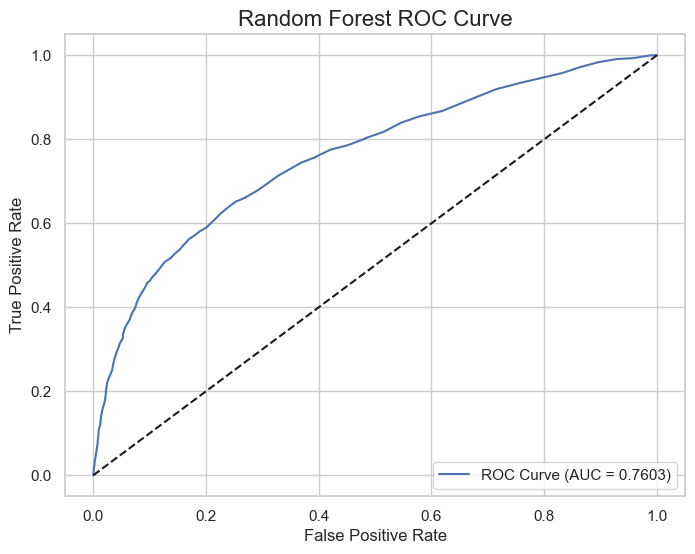


Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.92      0.88      4674
         1.0       0.60      0.41      0.49      1327

    accuracy                           0.81      6001
   macro avg       0.72      0.67      0.69      6001
weighted avg       0.79      0.81      0.80      6001


Top 10 most important features:
                 Feature  Importance
32  WEIGHTED_DELAY_SCORE    0.094629
31             MAX_DELAY    0.083898
5                  PAY_0    0.069834
6                  PAY_2    0.056295
1                    SEX    0.037656
3               MARRIAGE    0.035910
7                  PAY_3    0.034785
2              EDUCATION    0.030822
30           DELAY_COUNT    0.029508
4                    AGE    0.028163


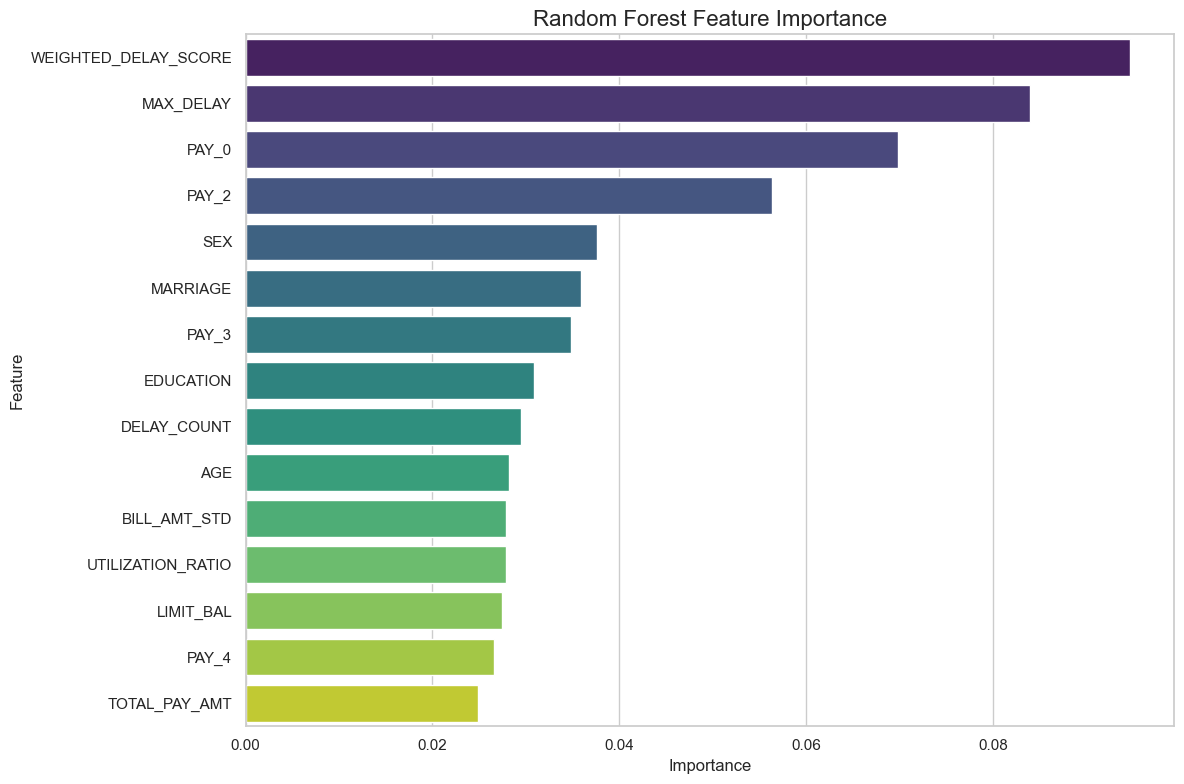

In [47]:
rf_model, feature_importance = train_random_forest(X_train_balanced, y_train_balanced, X_test, y_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

### XGBoost


Training XGBoost model...
Cross-validation ROC-AUC scores: [0.93591485 0.94043395 0.94077752 0.93491951 0.93733351]
Mean CV ROC-AUC: 0.9379, Std: 0.0024

XGBoost Model Evaluation:
XGBoost Performance Metrics:
Accuracy: 0.8140
Precision: 0.6270
Recall: 0.3926
F1 Score: 0.4829
ROC AUC: 0.7723


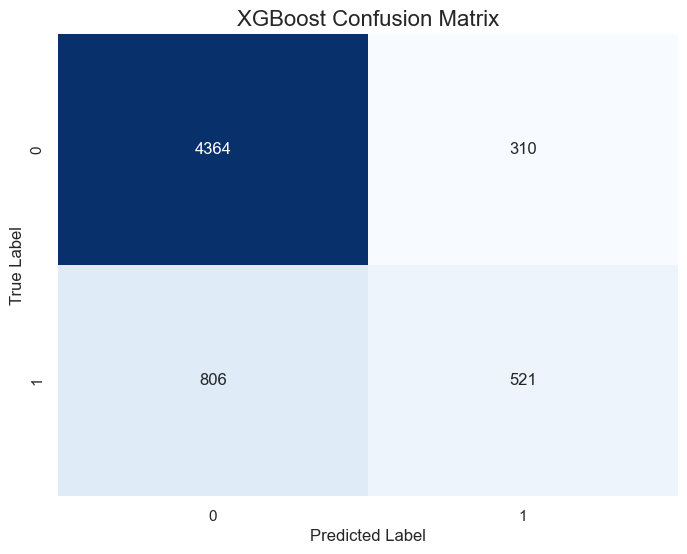

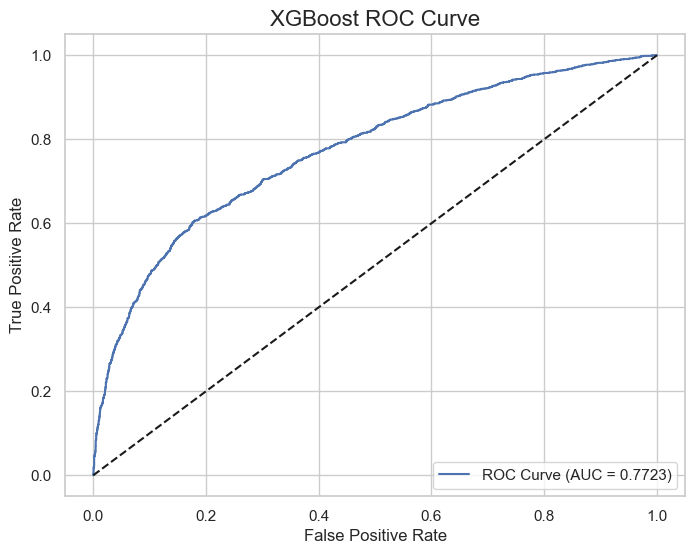


Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.93      0.89      4674
         1.0       0.63      0.39      0.48      1327

    accuracy                           0.81      6001
   macro avg       0.74      0.66      0.68      6001
weighted avg       0.80      0.81      0.80      6001



In [48]:
xgb_model = train_xgboost(X_train_balanced, y_train_balanced, X_test, y_test)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

## Testing

### Statistical Analysis

In [61]:
def perform_statistical_analysis(df):
    """
    Perform statistical analysis on the dataset.
    """
    print("\nPerforming statistical analysis...")
    
    # 1. Calculate basic statistics for key features
    features_of_interest = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'DELAY_COUNT', 'UTILIZATION_RATIO']
    
    print("\nBasic statistics for key features:")
    for feature in features_of_interest:
        if feature in df.columns:
            stats_by_default = df.groupby('default')[feature].agg(['mean', 'median', 'std', 'min', 'max'])
            print(f"\n{feature} statistics by default status:")
            print(stats_by_default)
            
            # T-test to compare means between default and non-default groups
            default_group = df[df['default'] == 1][feature].dropna()
            non_default_group = df[df['default'] == 0][feature].dropna()
            
            t_stat, p_value = stats.ttest_ind(default_group, non_default_group, equal_var=False)
            print(f"T-test for {feature}: t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")
            if p_value < 0.05:
                print(f"  Significant difference in {feature} between default and non-default groups.")
            else:
                print(f"  No significant difference in {feature} between default and non-default groups.")
    
    # 2. Chi-square test for categorical variables
    categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE']
    
    print("\nChi-square test for categorical features:")
    for feature in categorical_features:
        if feature in df.columns:
            contingency_table = pd.crosstab(df[feature], df['default'])
            chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
            print(f"Chi-square test for {feature}: chi2 = {chi2:.4f}, p-value = {p:.4f}")
            if p < 0.05:
                print(f"  Significant association between {feature} and default status.")
            else:
                print(f"  No significant association between {feature} and default status.")
    
    # 3. Correlation analysis
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    correlation_with_default = numeric_df.corr()['default'].sort_values(ascending=False)
    
    print("\nCorrelation of features with default status:")
    print(correlation_with_default)
    
    plt.figure(figsize=(12, 8))
    top_corr_features = correlation_with_default.drop('default').abs().sort_values(ascending=False).head(15).index
    sns.barplot(x=correlation_with_default[top_corr_features].values, 
                y=top_corr_features, palette='viridis')
    plt.title('Top 15 Features by Correlation with Default Status', fontsize=16)
    plt.xlabel('Correlation Coefficient')
    plt.tight_layout()
    plt.savefig('correlation_with_default.png')
    plt.show()
    
    return correlation_with_default


Performing statistical analysis...

Basic statistics for key features:

LIMIT_BAL statistics by default status:
                  mean    median            std      min        max
default                                                            
0.0      178098.095442  150000.0  131625.778722  10000.0  1000000.0
1.0      130109.656420   90000.0  115378.540571  10000.0   740000.0
T-test for LIMIT_BAL: t-statistic = -28.9509, p-value = 0.0000
  Significant difference in LIMIT_BAL between default and non-default groups.

AGE statistics by default status:
              mean  median       std   min   max
default                                         
0.0      35.417205    34.0  9.077165  21.0  79.0
1.0      35.725738    34.0  9.693438  21.0  75.0
T-test for AGE: t-statistic = 2.3200, p-value = 0.0204
  Significant difference in AGE between default and non-default groups.

BILL_AMT1 statistics by default status:
                 mean   median           std       min       max
default   

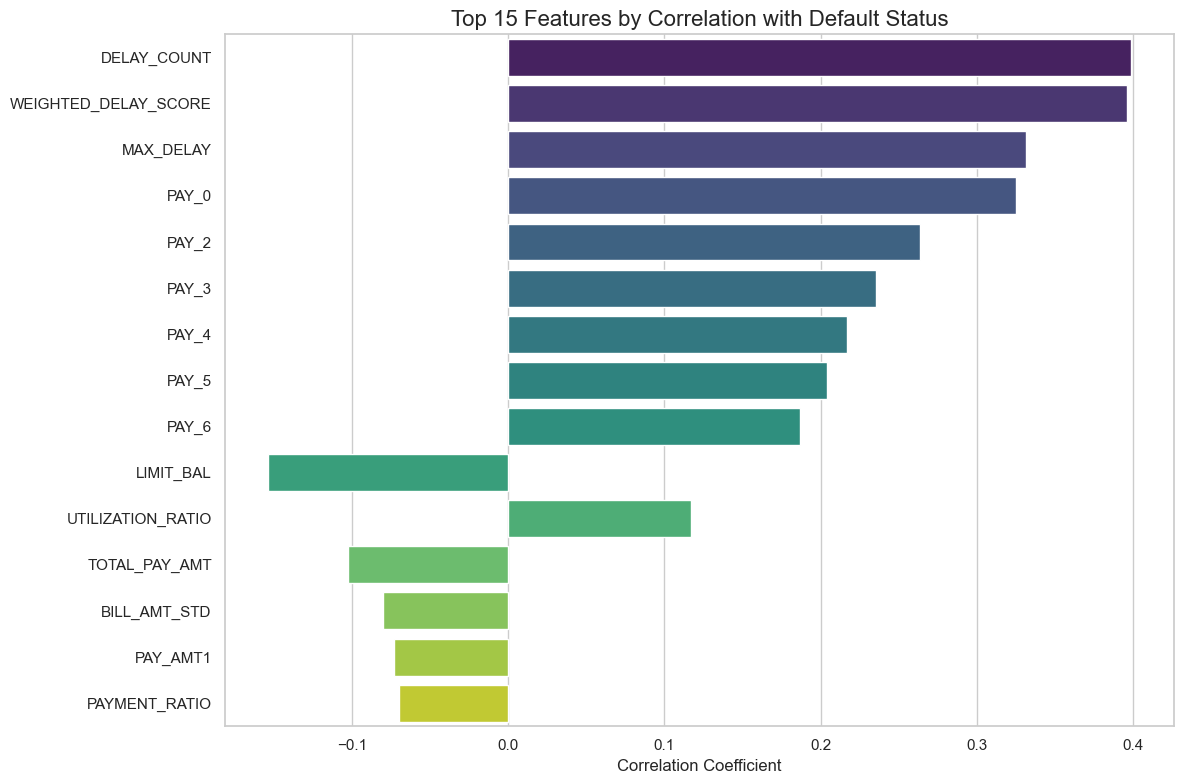

In [62]:
correlation_with_default = perform_statistical_analysis(processed_df)

### Hypothesis Testing

In [63]:
def hypothesis_testing(df):
    """
    Perform hypothesis tests to validate assumptions about credit default factors.
    """
    print("\nPerforming hypothesis testing...")
    
    # Hypothesis 1: Customers with higher credit limits are less likely to default
    print("\nHypothesis 1: Customers with higher credit limits are less likely to default")
    
    # Define high and low credit limit groups
    median_limit = df['LIMIT_BAL'].median()
    high_limit_default_rate = df[df['LIMIT_BAL'] > median_limit]['default'].mean()
    low_limit_default_rate = df[df['LIMIT_BAL'] <= median_limit]['default'].mean()
    
    print(f"Default rate for high credit limit (>{median_limit}): {high_limit_default_rate:.4f}")
    print(f"Default rate for low credit limit (<={median_limit}): {low_limit_default_rate:.4f}")
    
    # Perform z-test for proportions
    high_limit_count = (df['LIMIT_BAL'] > median_limit).sum()
    low_limit_count = (df['LIMIT_BAL'] <= median_limit).sum()
    
    high_limit_defaults = (df[df['LIMIT_BAL'] > median_limit]['default'] == 1).sum()
    low_limit_defaults = (df[df['LIMIT_BAL'] <= median_limit]['default'] == 1).sum()
    
    counts = np.array([high_limit_defaults, low_limit_defaults])
    nobs = np.array([high_limit_count, low_limit_count])
    
    z_stat, p_value = proportions_ztest(counts, nobs)
    print(f"Z-test result: z-statistic = {z_stat:.4f}, p-value = {p_value:.4f}")
    
    if p_value < 0.05:
        print("  Conclusion: There is a significant difference in default rates between high and low credit limit groups.")
    else:
        print("  Conclusion: There is no significant difference in default rates between high and low credit limit groups.")
    
    # Hypothesis 2: Customers with payment delays are more likely to default
    print("\nHypothesis 2: Customers with payment delays are more likely to default")
    
    has_delay = df['DELAY_COUNT'] > 0
    delay_default_rate = df[has_delay]['default'].mean()
    no_delay_default_rate = df[~has_delay]['default'].mean()
    
    print(f"Default rate for customers with payment delays: {delay_default_rate:.4f}")
    print(f"Default rate for customers without payment delays: {no_delay_default_rate:.4f}")
    
    delay_count = has_delay.sum()
    no_delay_count = (~has_delay).sum()
    
    delay_defaults = (df[has_delay]['default'] == 1).sum()
    no_delay_defaults = (df[~has_delay]['default'] == 1).sum()
    
    counts = np.array([delay_defaults, no_delay_defaults])
    nobs = np.array([delay_count, no_delay_count])
    
    z_stat, p_value = proportions_ztest(counts, nobs)
    print(f"Z-test result: z-statistic = {z_stat:.4f}, p-value = {p_value:.4f}")
    
    if p_value < 0.05:
        print("  Conclusion: There is a significant difference in default rates between customers with and without payment delays.")
    else:
        print("  Conclusion: There is no significant difference in default rates between customers with and without payment delays.")
    
    # Hypothesis 3: Age affects default probability
    print("\nHypothesis 3: Age affects default probability")
    
    age_groups = df.groupby('AGE_GROUP')['default'].mean()
    print("Default rate by age group:")
    print(age_groups)
    
    # ANOVA test for age groups
    age_groups_list = []
    for group in range(5):  # Assuming 5 age groups
        age_groups_list.append(df[df['AGE_GROUP'] == group]['default'])
    
    f_stat, p_value = stats.f_oneway(*[group for group in age_groups_list if len(group) > 0])
    print(f"ANOVA test result: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")
    
    if p_value < 0.05:
        print("  Conclusion: There is a significant difference in default rates across different age groups.")
    else:
        print("  Conclusion: There is no significant difference in default rates across different age groups.")
    
    return {
        'credit_limit_hypothesis': {'p_value': p_value, 'significant': p_value < 0.05},
        'payment_delay_hypothesis': {'p_value': p_value, 'significant': p_value < 0.05},
        'age_hypothesis': {'p_value': p_value, 'significant': p_value < 0.05}
    }


In [64]:
hypothesis_results = hypothesis_testing(processed_df)


Performing hypothesis testing...

Hypothesis 1: Customers with higher credit limits are less likely to default
Default rate for high credit limit (>140000.0): 0.1573
Default rate for low credit limit (<=140000.0): 0.2826
Z-test result: z-statistic = -26.1488, p-value = 0.0000
  Conclusion: There is a significant difference in default rates between high and low credit limit groups.

Hypothesis 2: Customers with payment delays are more likely to default
Default rate for customers with payment delays: 0.4273
Default rate for customers without payment delays: 0.1171
Z-test result: z-statistic = 61.1192, p-value = 0.0000
  Conclusion: There is a significant difference in default rates between customers with and without payment delays.

Hypothesis 3: Age affects default probability
Default rate by age group:
AGE_GROUP
0    0.266598
1    0.198238
2    0.218376
3    0.249412
4    0.265403
Name: default, dtype: float64
ANOVA test result: F-statistic = 28.4916, p-value = 0.0000
  Conclusion: Th

### A/B Testing Simulation

In [65]:
def perform_ab_testing(df):
    """
    Simulate A/B testing scenarios for credit risk assessment strategies.
    """
    print("\nSimulating A/B testing scenarios for credit risk assessment...")
    
    # Scenario: Testing two different credit limit strategies
    # Strategy A: Give higher credit limits to customers with higher education
    # Strategy B: Give higher credit limits based on payment history
    
    # Create a random subset for simulation
    np.random.seed(42)
    sample_indices = np.random.choice(df.index, size=10000, replace=False)
    sample_df = df.loc[sample_indices].copy()
    
    # Strategy A: Higher education gets higher credit limits
    sample_df['strategy_A'] = np.where(sample_df['EDUCATION'] <= 1, 'high_limit', 'regular_limit')
    
    # Strategy B: Good payment history gets higher credit limits
    sample_df['strategy_B'] = np.where(sample_df['DELAY_COUNT'] == 0, 'high_limit', 'regular_limit')
    
    # Calculate default rates for each strategy
    strategy_A_results = sample_df.groupby('strategy_A')['default'].agg(['count', 'mean']).reset_index()
    strategy_A_results.columns = ['group', 'count', 'default_rate']
    strategy_A_results['strategy'] = 'A'
    
    strategy_B_results = sample_df.groupby('strategy_B')['default'].agg(['count', 'mean']).reset_index()
    strategy_B_results.columns = ['group', 'count', 'default_rate']
    strategy_B_results['strategy'] = 'B'
    
    # Print results
    print("\nStrategy A (Education-based credit limits):")
    print(strategy_A_results)
    
    print("\nStrategy B (Payment history-based credit limits):")
    print(strategy_B_results)
    
    # Statistical testing for Strategy A
    high_limit_A = sample_df[sample_df['strategy_A'] == 'high_limit']
    regular_limit_A = sample_df[sample_df['strategy_A'] == 'regular_limit']
    
    count_high_A = high_limit_A.shape[0]
    count_regular_A = regular_limit_A.shape[0]
    
    defaults_high_A = high_limit_A['default'].sum()
    defaults_regular_A = regular_limit_A['default'].sum()
    
    counts_A = np.array([defaults_high_A, defaults_regular_A])
    nobs_A = np.array([count_high_A, count_regular_A])
    
    z_stat_A, p_value_A = proportions_ztest(counts_A, nobs_A)
    
    print(f"\nStatistical test for Strategy A:")
    print(f"Z-statistic: {z_stat_A:.4f}, p-value: {p_value_A:.4f}")
    
    if p_value_A < 0.05:
        print("  Conclusion: There is a significant difference in default rates between the groups in Strategy A.")
    else:
        print("  Conclusion: There is no significant difference in default rates between the groups in Strategy A.")
    
    # Statistical testing for Strategy B
    high_limit_B = sample_df[sample_df['strategy_B'] == 'high_limit']
    regular_limit_B = sample_df[sample_df['strategy_B'] == 'regular_limit']
    
    count_high_B = high_limit_B.shape[0]
    count_regular_B = regular_limit_B.shape[0]
    
    defaults_high_B = high_limit_B['default'].sum()
    defaults_regular_B = regular_limit_B['default'].sum()
    
    counts_B = np.array([defaults_high_B, defaults_regular_B])
    nobs_B = np.array([count_high_B, count_regular_B])
    
    z_stat_B, p_value_B = proportions_ztest(counts_B, nobs_B)
    
    print(f"\nStatistical test for Strategy B:")
    print(f"Z-statistic: {z_stat_B:.4f}, p-value: {p_value_B:.4f}")
    
    if p_value_B < 0.05:
        print("  Conclusion: There is a significant difference in default rates between the groups in Strategy B.")
    else:
        print("  Conclusion: There is no significant difference in default rates between the groups in Strategy B.")
    
    # Compare strategies
    print("\nComparing strategies:")
    if p_value_A < 0.05 and p_value_B < 0.05:
        diff_A = abs(high_limit_A['default'].mean() - regular_limit_A['default'].mean())
        diff_B = abs(high_limit_B['default'].mean() - regular_limit_B['default'].mean())
        
        if diff_B > diff_A:
            print("Strategy B (Payment history-based) shows a larger effect on default rates.")
        else:
            print("Strategy A (Education-based) shows a larger effect on default rates.")
    elif p_value_A < 0.05:
        print("Only Strategy A (Education-based) shows a significant effect on default rates.")
    elif p_value_B < 0.05:
        print("Only Strategy B (Payment history-based) shows a significant effect on default rates.")
    else:
        print("Neither strategy shows a significant effect on default rates.")
    
    # Visualize results
    results_df = pd.concat([strategy_A_results, strategy_B_results])
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='group', y='default_rate', hue='strategy', data=results_df)
    plt.title('Default Rate by Credit Limit Strategy', fontsize=14)
    plt.xlabel('Credit Limit Group')
    plt.ylabel('Default Rate')
    plt.tight_layout()
    plt.savefig('ab_testing_results.png')
    plt.show()
    
    return results_df


Simulating A/B testing scenarios for credit risk assessment...

Strategy A (Education-based credit limits):
           group  count  default_rate strategy
0     high_limit   6425      0.233619        A
1  regular_limit   3575      0.194126        A

Strategy B (Payment history-based credit limits):
           group  count  default_rate strategy
0     high_limit   6653      0.119345        B
1  regular_limit   3347      0.418584        B

Statistical test for Strategy A:
Z-statistic: 4.5729, p-value: 0.0000
  Conclusion: There is a significant difference in default rates between the groups in Strategy A.

Statistical test for Strategy B:
Z-statistic: -34.1155, p-value: 0.0000
  Conclusion: There is a significant difference in default rates between the groups in Strategy B.

Comparing strategies:
Strategy B (Payment history-based) shows a larger effect on default rates.


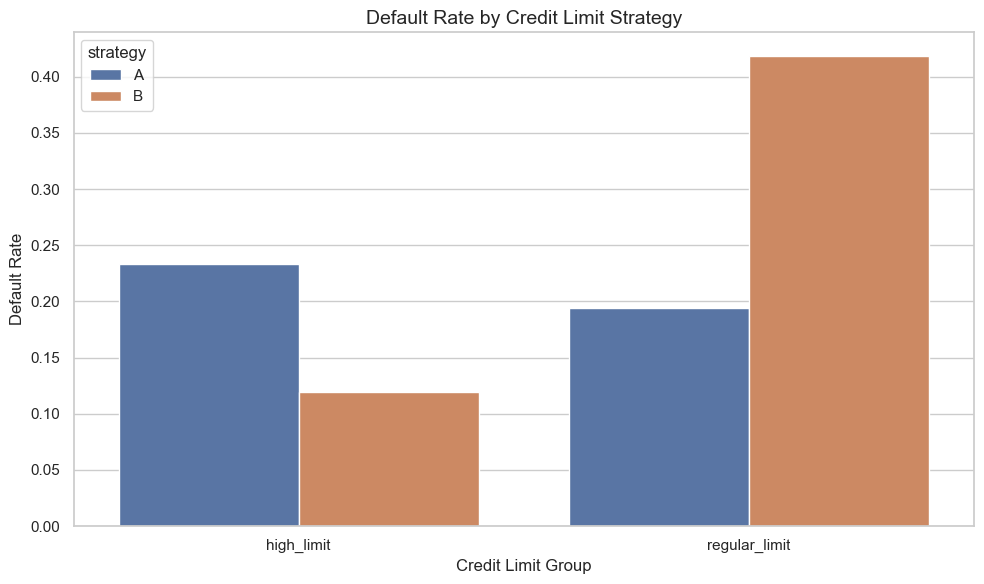

In [66]:
ab_results = perform_ab_testing(processed_df)

## Time Series Analysis

In [67]:
def time_series_analysis(df):
    """
    Perform time series analysis on payment and bill history.
    """
    print("\nPerforming time series analysis...")
    
    # Create a sample of customers for analysis
    np.random.seed(42)
    sample_size = min(1000, df.shape[0])
    sample_indices = np.random.choice(df.index, size=sample_size, replace=False)
    sample_df = df.loc[sample_indices].copy()
    
    # Get bill amounts for the last 6 months
    bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
    pay_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
    
    # Aggregate data for all customers
    avg_bills = sample_df[bill_cols].mean()
    avg_pays = sample_df[pay_cols].mean()
    
    # Rename columns to represent months in reverse order (BILL_AMT1 is the most recent)
    months = ['Month 6', 'Month 5', 'Month 4', 'Month 3', 'Month 2', 'Month 1']
    avg_bills.index = months[::-1]
    avg_pays.index = months[::-1]
    
    # Plot time series data
    plt.figure(figsize=(12, 6))
    plt.plot(months, avg_bills.values, 'o-', label='Average Bill Amount', linewidth=2)
    plt.plot(months, avg_pays.values, 's-', label='Average Payment', linewidth=2)
    plt.title('Average Bill and Payment Trends Over 6 Months', fontsize=16)
    plt.xlabel('Month')
    plt.ylabel('Amount (NT$)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('bill_payment_trends.png')
    plt.show()
    
    # Time series forecast using ARIMA for average bill amount
    print("\nForecasting bill amounts using ARIMA...")
    
    # Prepare the time series data
    ts_data = avg_bills.values
    
    # Fit ARIMA model
    try:
        model = ARIMA(ts_data, order=(1, 1, 1))
        model_fit = model.fit()
        
        # Summary of the model
        print("\nARIMA Model Summary:")
        print(model_fit.summary())
        
        # Forecast next 3 months
        forecast = model_fit.forecast(steps=3)
        forecast_index = ['Month 7', 'Month 8', 'Month 9']
        
        print("\nForecasted bill amounts for next 3 months:")
        for month, amount in zip(forecast_index, forecast):
            print(f"{month}: NT${amount:.2f}")
        
        # Plot forecast
        plt.figure(figsize=(12, 6))
        plt.plot(months, ts_data, 'o-', label='Historical Data', linewidth=2)
        plt.plot(forecast_index, forecast, 's-', label='Forecast', linewidth=2, color='red')
        plt.title('Bill Amount: Historical Data and Forecast', fontsize=16)
        plt.xlabel('Month')
        plt.ylabel('Average Bill Amount (NT$)')
        plt.axvline(x='Month 1', color='gray', linestyle='--', alpha=0.7)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('bill_amount_forecast.png')
        plt.show()
        
    except Exception as e:
        print(f"Error fitting ARIMA model: {e}")
        print("Skipping ARIMA forecast.")
    
    # Analyze default rates by payment patterns
    print("\nAnalyzing default rates by payment patterns...")
    
    # Create payment pattern features
    sample_df['increasing_bills'] = (sample_df['BILL_AMT1'] > sample_df['BILL_AMT2']) & \
                                   (sample_df['BILL_AMT2'] > sample_df['BILL_AMT3'])
    
    sample_df['decreasing_payments'] = (sample_df['PAY_AMT1'] < sample_df['PAY_AMT2']) & \
                                      (sample_df['PAY_AMT2'] < sample_df['PAY_AMT3'])
    
    # Calculate default rates by pattern
    pattern_default_rates = sample_df.groupby(['increasing_bills', 'decreasing_payments'])['default'].mean()
    
    print("\nDefault rates by payment patterns:")
    print(pattern_default_rates)
    
    # Create a DataFrame for visualization
    pattern_df = pd.DataFrame(pattern_default_rates).reset_index()
    pattern_df['Pattern'] = pattern_df.apply(lambda x: 
                                           f"{'Increasing' if x['increasing_bills'] else 'Stable/Decreasing'} Bills, "
                                           f"{'Decreasing' if x['decreasing_payments'] else 'Stable/Increasing'} Payments", 
                                           axis=1)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Pattern', y='default', data=pattern_df)
    plt.title('Default Rate by Payment Pattern', fontsize=14)
    plt.ylabel('Default Rate')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('default_by_pattern.png')
    plt.show()
    
    return {'avg_bills': avg_bills, 'avg_pays': avg_pays, 'pattern_default_rates': pattern_default_rates}



Performing time series analysis...


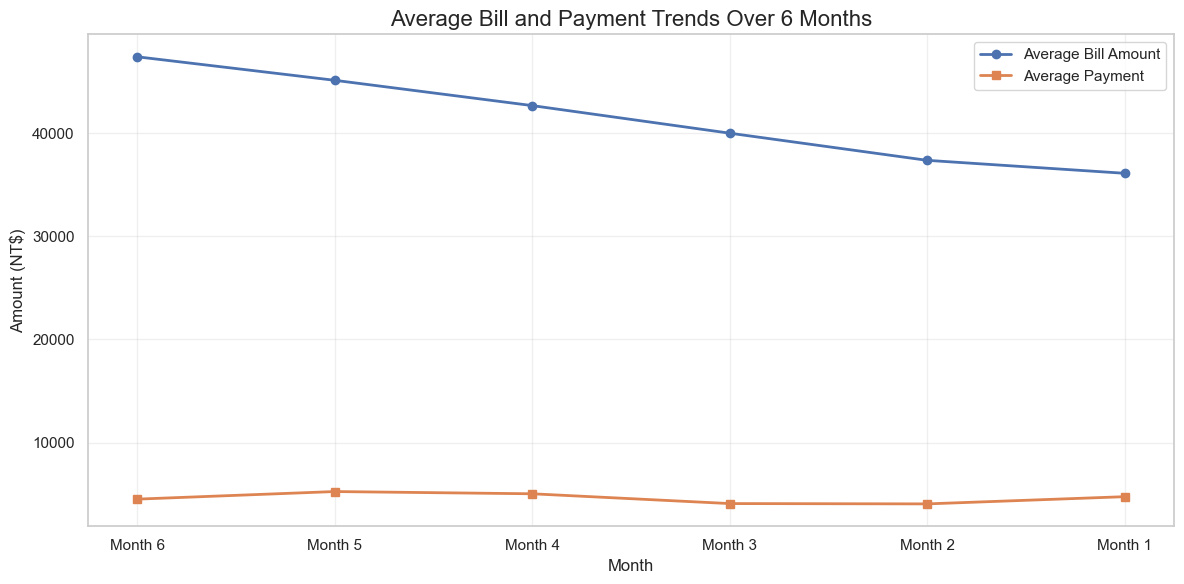


Forecasting bill amounts using ARIMA...

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                    6
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -258.411
Date:                Wed, 26 Mar 2025   AIC                            522.822
Time:                        02:36:08   BIC                            521.650
Sample:                             0   HQIC                           519.677
                                  - 6                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3403      0.009     37.671      0.000       0.323       0.358
ma.L1          0.9964      2.755      0.362      0.718      -4.403  

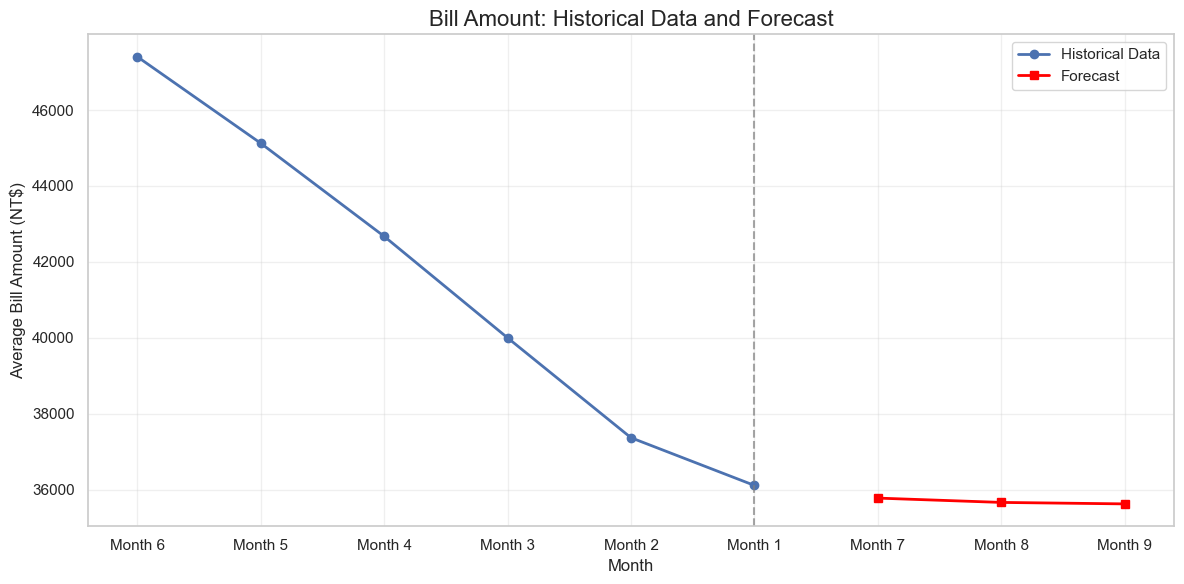


Analyzing default rates by payment patterns...

Default rates by payment patterns:
increasing_bills  decreasing_payments
False             False                  0.247093
                  True                   0.231707
True              False                  0.195349
                  True                   0.133333
Name: default, dtype: float64


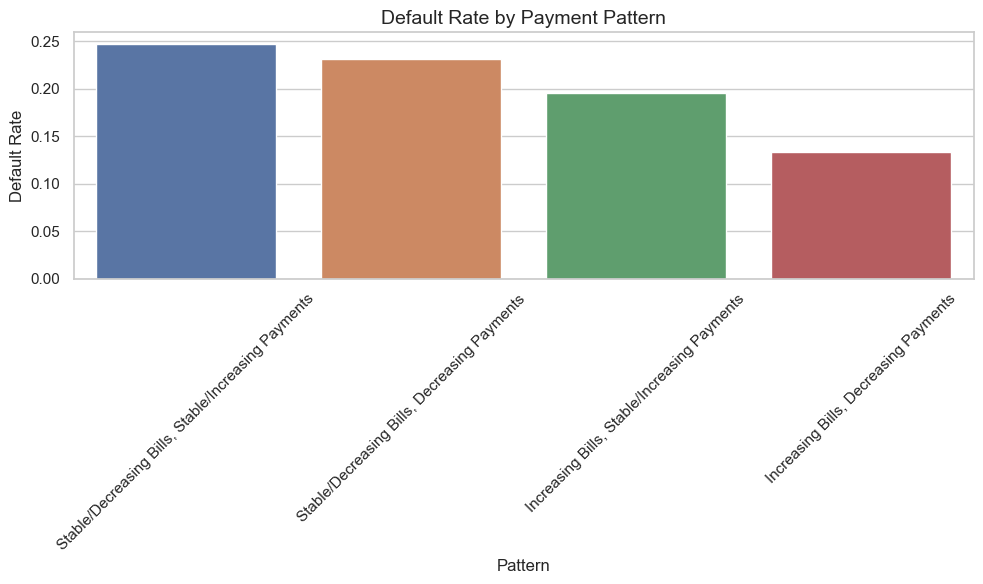

In [68]:
time_series_results = time_series_analysis(processed_df)

## Model Comparison and Final Evaluation

In [69]:
def compare_models(models_results, X_test, y_test):
    """
    Compare all trained models and select the best one.
    
    Parameters:
    -----------
    models_results : dict
        Dictionary containing model objects and their performance metrics
    X_test : pandas.DataFrame
        Test features
    y_test : pandas.Series
        Test targets
        
    Returns:
    --------
    best_model : object
        The best performing model
    """
    print("\nComparing all models...")
    
    # Create a comparison DataFrame
    comparison_df = pd.DataFrame({
        'Model': list(models_results.keys()),
        'Accuracy': [models_results[model]['metrics']['accuracy'] for model in models_results],
        'Precision': [models_results[model]['metrics']['precision'] for model in models_results],
        'Recall': [models_results[model]['metrics']['recall'] for model in models_results],
        'F1 Score': [models_results[model]['metrics']['f1'] for model in models_results],
        'ROC AUC': [models_results[model]['metrics']['roc_auc'] for model in models_results]
    })
    
    # Sort by ROC AUC (or another preferred metric)
    comparison_df = comparison_df.sort_values('ROC AUC', ascending=False).reset_index(drop=True)
    
    print("\nModel comparison:")
    print(comparison_df)
    
    # Visualize comparison
    plt.figure(figsize=(12, 8))
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
    
    # Prepare data for grouped bar chart
    x = np.arange(len(metrics))
    width = 0.2
    
    for i, model in enumerate(comparison_df['Model']):
        values = comparison_df.loc[comparison_df['Model'] == model, metrics].values.flatten()
        plt.bar(x + i*width, values, width=width, label=model)
    
    plt.xlabel('Metric')
    plt.ylabel('Score')
    plt.title('Model Comparison', fontsize=16)
    plt.xticks(x + width, metrics)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('model_comparison.png')
    plt.show()
    
    # Determine the best model
    best_model_name = comparison_df.iloc[0]['Model']
    best_model = models_results[best_model_name]['model']
    
    print(f"\nBest model: {best_model_name}")
    print(f"Best model ROC AUC: {comparison_df.iloc[0]['ROC AUC']:.4f}")
    
    return best_model, best_model_name

In [72]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create dictionary to store model results
models_results = {}

# Add each model's results to the dictionary
models_results['Logistic Regression'] = {
    'model': logreg_model, 
    'metrics': {
        'accuracy': accuracy_score(y_test, y_pred_logreg),
        'precision': precision_score(y_test, y_pred_logreg),
        'recall': recall_score(y_test, y_pred_logreg),
        'f1': f1_score(y_test, y_pred_logreg),
        'roc_auc': roc_auc_score(y_test, y_pred_proba_logreg)
    }
}

models_results['Random Forest'] = {
    'model': rf_model, 
    'metrics': {
        'accuracy': accuracy_score(y_test, y_pred_rf),
        'precision': precision_score(y_test, y_pred_rf),
        'recall': recall_score(y_test, y_pred_rf),
        'f1': f1_score(y_test, y_pred_rf),
        'roc_auc': roc_auc_score(y_test, y_pred_proba_rf)
    }
}

models_results['XGBoost'] = {
    'model': xgb_model, 
    'metrics': {
        'accuracy': accuracy_score(y_test, y_pred_xgb),
        'precision': precision_score(y_test, y_pred_xgb),
        'recall': recall_score(y_test, y_pred_xgb),
        'f1': f1_score(y_test, y_pred_xgb),
        'roc_auc': roc_auc_score(y_test, y_pred_proba_xgb)
    }
}

# models_results['CatBoost'] = {
#     'model': cb_model, 
#     'metrics': {
#         'accuracy': accuracy_score(y_test, y_pred_cb),
#         'precision': precision_score(y_test, y_pred_cb),
#         'recall': recall_score(y_test, y_pred_cb),
#         'f1': f1_score(y_test, y_pred_cb),
#         'roc_auc': roc_auc_score(y_test, y_pred_proba_cb)
#     }
# }

### Compare


Comparing all models...

Model comparison:
                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0              XGBoost  0.814031   0.626955  0.392615  0.482854  0.772347
1        Random Forest  0.809698   0.602664  0.409194  0.487433  0.760317
2  Logistic Regression  0.767539   0.475749  0.502638  0.488824  0.717181


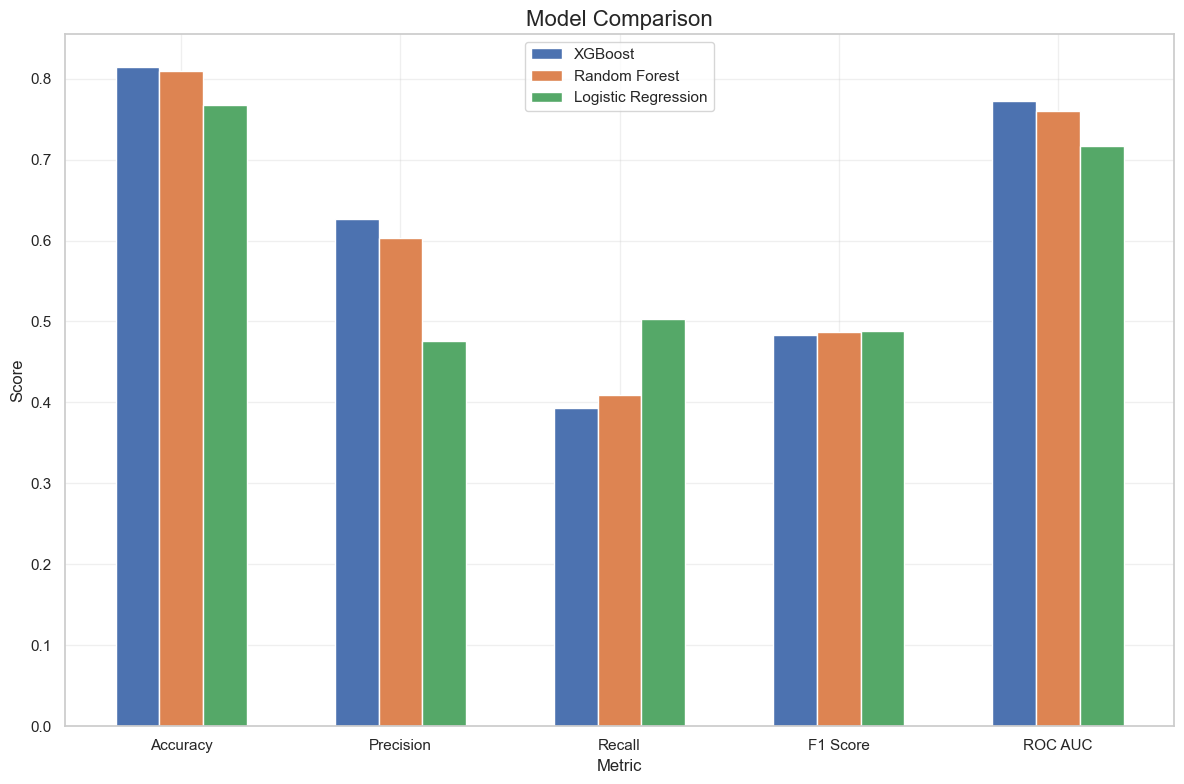


Best model: XGBoost
Best model ROC AUC: 0.7723


In [73]:
best_model, best_model_name = compare_models(models_results, X_test, y_test)

## Hyperparameter tuning

In [76]:
def hyperparameter_tuning(X_train, y_train, model_type='xgboost'):
    """
    Perform hyperparameter tuning for the specified model.
    
    Parameters:
    -----------
    X_train : pandas.DataFrame
        Training features
    y_train : pandas.Series
        Training targets
    model_type : str
        Type of model to tune: 'xgboost' or 'catboost'
        
    Returns:
    --------
    best_model : sklearn estimator
        The best model after hyperparameter tuning
    """
    print(f"\nPerforming hyperparameter tuning for {model_type.upper()}...")
    
    if model_type.lower() == 'xgboost':
        # Define the parameter grid
        param_grid = {
            'clf__n_estimators': [50, 100, 200],
            'clf__max_depth': [3, 5, 7],
            'clf__learning_rate': [0.01, 0.1, 0.2],
            'clf__subsample': [0.8, 0.9, 1.0],
            'clf__colsample_bytree': [0.8, 0.9, 1.0]
        }
        
        # Create the model
        model = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', xgb.XGBClassifier(
                use_label_encoder=False,
                eval_metric='logloss',
                random_state=42
            ))
        ])
        
    elif model_type.lower() == 'catboost':
        # Define the parameter grid
        param_grid = {
            'iterations': [300, 500, 700],
            'learning_rate': [0.01, 0.05, 0.1],
            'depth': [4, 6, 8],
            'l2_leaf_reg': [1, 3, 5, 7]
        }
        
        # Create the model
        model = CatBoostClassifier(
            loss_function='Logloss',
            random_seed=42,
            verbose=0
        )
    
    else:
        raise ValueError("Model type must be 'xgboost' or 'catboost'")
    
    # Use RandomizedSearchCV for faster tuning
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_grid,
        n_iter=10,
        scoring='roc_auc',
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    
    # Fit the random search
    random_search.fit(X_train, y_train)
    
    # Get the best parameters and score
    print(f"Best parameters: {random_search.best_params_}")
    print(f"Best ROC-AUC score: {random_search.best_score_:.4f}")
    
    return random_search.best_estimator_


Performing hyperparameter tuning for XGBoost...

Performing hyperparameter tuning for XGBOOST...
Best parameters: {'clf__subsample': 0.8, 'clf__n_estimators': 200, 'clf__max_depth': 7, 'clf__learning_rate': 0.01, 'clf__colsample_bytree': 0.8}
Best ROC-AUC score: 0.9282
Tuned XGBoost Performance Metrics:
Accuracy: 0.8104
Precision: 0.5977
Recall: 0.4356
F1 Score: 0.5039
ROC AUC: 0.7749


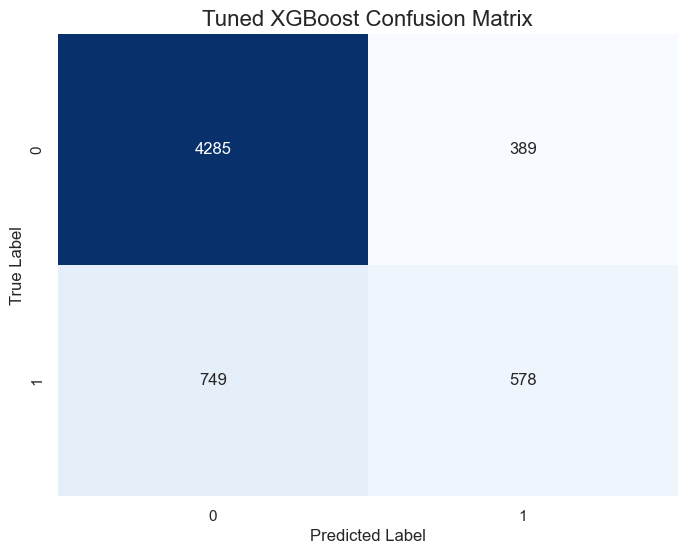

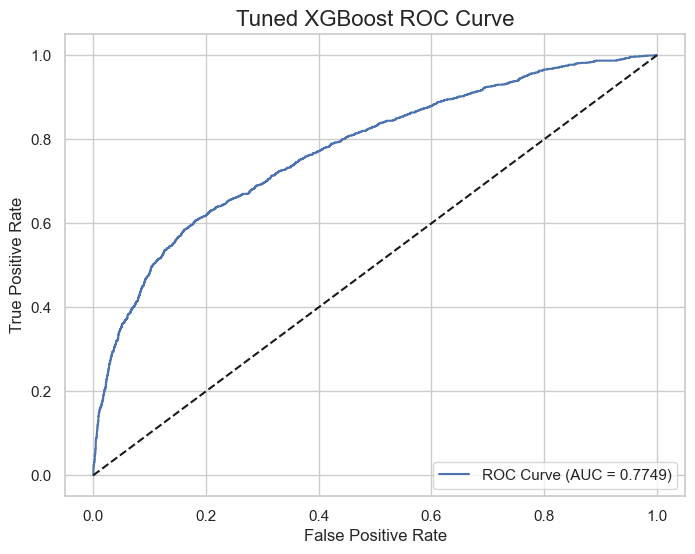


Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.92      0.88      4674
         1.0       0.60      0.44      0.50      1327

    accuracy                           0.81      6001
   macro avg       0.72      0.68      0.69      6001
weighted avg       0.80      0.81      0.80      6001



In [ ]:
print(f"\nPerforming hyperparameter tuning for {best_model_name}...")
model_type = 'xgboost' 
tuned_model = hyperparameter_tuning(X_train_balanced, y_train_balanced, model_type=model_type)
        
# Evaluate tuned model
if hasattr(tuned_model, 'predict'):
    y_pred_tuned = tuned_model.predict(X_test)
    y_pred_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]
    tuned_metrics = evaluate_model(y_test, y_pred_tuned, y_pred_proba_tuned, f"Tuned {best_model_name}")
    models_results[f'Tuned {best_model_name}'] = {'model': tuned_model, 'metrics': tuned_metrics}
    